In [1]:
erre=2.9

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def step1_two_trajectories(r, x0=0.2, epsilon=1e-8, n_iter=80):
    t = np.arange(n_iter)
    x1 = np.zeros(n_iter)
    x2 = np.zeros(n_iter)
    x1[0] = x0
    x2[0] = x0 + epsilon

    for i in range(n_iter - 1):
        x1[i+1] = r * x1[i] * (1 - x1[i])
        x2[i+1] = r * x2[i] * (1 - x2[i])

    plt.figure(figsize=(10,4))
    plt.plot(t, x1, 'b-o', lw=1.5, label=f'$x_t$ ($x_0={x0}$)', alpha=0.8)
    plt.plot(t, x2, 'r--x', lw=1.5, label=f"$x'_t$ ($x'_0={x0+epsilon}$)", alpha=0.8)
    plt.title(f"Step 1: Two nearby trajectories (r={r})")
    plt.xlabel("t")
    plt.ylabel(r"$x_t$")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()




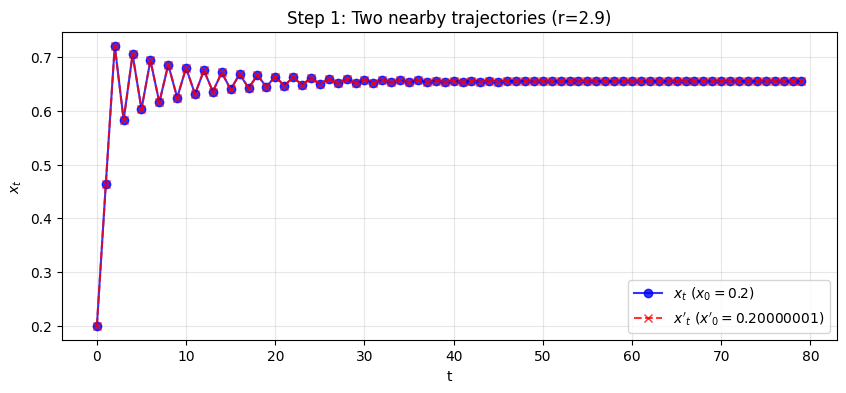

In [3]:
step1_two_trajectories(r=erre)

In [4]:
def step2_log_distance(r, x0=0.2, epsilon=1e-8, n_iter=120):
    t = np.arange(n_iter)
    x1 = np.zeros(n_iter)
    x2 = np.zeros(n_iter)
    x1[0] = x0
    x2[0] = x0 + epsilon

    for i in range(n_iter - 1):
        x1[i+1] = r * x1[i] * (1 - x1[i])
        x2[i+1] = r * x2[i] * (1 - x2[i])

    diff = np.abs(x1 - x2)

    plt.figure(figsize=(10,4))
    plt.plot(t, diff, lw=1.5)
    plt.yscale("log")
    plt.title(f"Step 2: Distance growth (log scale) (r={r})")
    plt.xlabel("t")
    plt.ylabel(r"$|x'_t - x_t|$")
    plt.grid(alpha=0.3)
    plt.show()



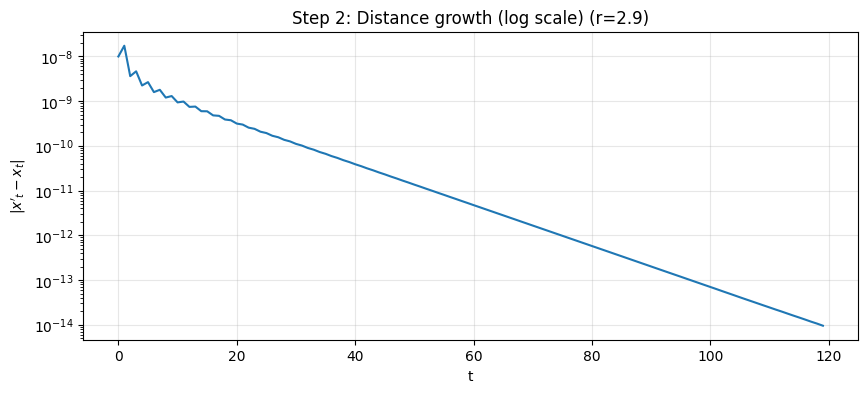

In [5]:
step2_log_distance(r=erre)

In [6]:
def step3_lambda_from_two_trajs(r, x0=0.2, epsilon=1e-8, n_iter=200, fit_window=(10, 60)):
    t = np.arange(n_iter)
    x1 = np.zeros(n_iter)
    x2 = np.zeros(n_iter)
    x1[0] = x0
    x2[0] = x0 + epsilon

    for i in range(n_iter - 1):
        x1[i+1] = r * x1[i] * (1 - x1[i])
        x2[i+1] = r * x2[i] * (1 - x2[i])

    diff = np.abs(x1 - x2)
    eps = 1e-16
    logdiff = np.log(diff + eps)

    a, b = fit_window
    coef = np.polyfit(t[a:b], logdiff[a:b], 1)
    lambda_hat = coef[0]

    plt.figure(figsize=(10,4))
    plt.plot(t, logdiff, lw=1.2, label="log distance")
    plt.plot(t[a:b], np.polyval(coef, t[a:b]), lw=4, label=f"fit slope ≈ {lambda_hat:.3f}")
    plt.title(f"Step 3: Estimate λ from log-distance slope (r={r})")
    plt.xlabel("t")
    plt.ylabel(r"$\ln |x'_t - x_t|$")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    return lambda_hat


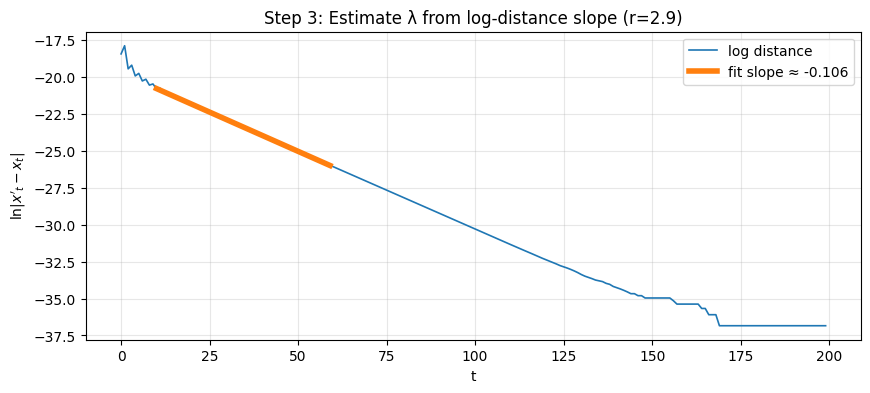

np.float64(-0.10635590358210043)

In [7]:
step3_lambda_from_two_trajs(erre)

In [8]:
def step4_lambda_derivative(r, x0=0.2, n_iter=2000, burn=200):
    x = x0
    lyap_sum = 0.0
    lyap_count = 0
    eps = 1e-12

    for i in range(n_iter):
        # derivative at current state (x_t)
        f_prime = abs(r * (1 - 2 * x))

        # after burn-in: accumulate Lyapunov
        if i >= burn:
            lyap_sum += np.log(f_prime + eps)
            lyap_count += 1

        # update to next state (x_{t+1})
        x = r * x * (1 - x)

    return lyap_sum / lyap_count



lambdaValue=step4_lambda_derivative(erre)
print(f'Cumulative Average {erre:.4f}:', lambdaValue)

Cumulative Average 2.9000: -0.10536051565661828


In [9]:
def lyapunov_insight(lambda_value, verbose=True, step_label="step"):
    """
    Translate a Lyapunov exponent (λ) into intuitive regime labels and
    practical horizons for prediction and recovery.

    Conventions:
      - λ > 0: errors grow exponentially (predictability horizon)
      - λ < 0: errors decay exponentially (recovery horizons)
      - λ ≈ 0: critical boundary (tipping / bifurcation)
    """

    # 1) Average multiplicative factor per step, and % change
    factor = float(np.exp(lambda_value))                 # e^λ
    percent_change = (factor - 1.0) * 100.0              # (e^λ - 1)*100

    # 2) Regime classification
    tol = 1e-12
    if lambda_value > tol:
        regime = "CHAOTIC (Sensitive to Initial Conditions)"
        logic = "λ > 0"
    elif lambda_value < -tol:
        regime = "STABLE (Self-Correcting)"
        logic = "λ < 0"
    else:
        regime = "CRITICAL (Boundary / Tipping Point)"
        logic = "λ ≈ 0"

    # 3) Horizons from E(t) = E0 * exp(λ t):  t = ln(multiplier) / λ
    def horizon(multiplier):
        if abs(lambda_value) < tol:
            return None
        return float(np.log(multiplier) / lambda_value)

    # Growth horizons (meaningful only if λ > 0)
    t_double = horizon(2.0)     # time to error ×2
    t_tenfold = horizon(10.0)   # time to error ×10

    # Decay horizons (meaningful only if λ < 0)
    t_half = horizon(0.5)       # time to error ×0.5
    t_tenth = horizon(0.1)      # time to error ×0.1

    if verbose:
        header = f" ANALYSIS FOR λ = {lambda_value:.4f} "
        print(f"\n{'='*len(header)}\n{header}\n{'='*len(header)}")
        print(f"Regime: {regime}  [{logic}]")
        print(f"Average error multiplier per {step_label}: {factor:.4f}")
        print(f"Average error change per {step_label}: {percent_change:+.2f}%")

        if lambda_value > tol:
            print(f"\n--- HORIZONS (Predictability Limits) ---")
            print(f"1. DOUBLING TIME: error ×2 in ~{t_double:.1f} {step_label}s.")
            print(f"2. TENFOLD TIME:  error ×10 in ~{t_tenfold:.1f} {step_label}s.")
            print(f"\n--- POLICY LESSON ---")
            print(
                "Forecasts degrade quickly. Prioritize rapid monitoring, short planning cycles, "
                "and adaptive policies within the predictability horizon."
            )

        elif lambda_value < -tol:
            print(f"\n--- HORIZONS (Recovery / Stability Metrics) ---")
            print(f"1. HALF-LIFE: errors halve in ~{t_half:.1f} {step_label}s.")
            print(f"2. 10× DECAY: errors shrink ×10 in ~{t_tenth:.1f} {step_label}s.")
            print(f"\n--- POLICY LESSON ---")
            print(
                "The system is resilient: small shocks decay endogenously. "
                "Policy can focus on monitoring and avoiding interventions that amplify volatility."
            )

        else:
            print(f"\n--- POLICY LESSON ---")
            print(
                "System is near a critical boundary (λ ≈ 0). Small changes can shift long-run behavior. "
                "Treat as a tipping-risk setting: monitor leading indicators and stress-test assumptions."
            )

    # Return only meaningful horizons for the regime
    out = {
        "lambda": float(lambda_value),
        "multiplier": factor,
        "growth_pct": percent_change,
        "regime": regime,
    }
    if lambda_value > tol:
        out.update({"t_double": t_double, "t_tenfold": t_tenfold})
    elif lambda_value < -tol:
        out.update({"t_half": t_half, "t_tenth": t_tenth})

    return out


In [10]:
lyapunov_insight(lambdaValue)


 ANALYSIS FOR λ = -0.1054 
Regime: STABLE (Self-Correcting)  [λ < 0]
Average error multiplier per step: 0.9000
Average error change per step: -10.00%

--- HORIZONS (Recovery / Stability Metrics) ---
1. HALF-LIFE: errors halve in ~6.6 steps.
2. 10× DECAY: errors shrink ×10 in ~21.9 steps.

--- POLICY LESSON ---
The system is resilient: small shocks decay endogenously. Policy can focus on monitoring and avoiding interventions that amplify volatility.


{'lambda': -0.10536051565661828,
 'multiplier': 0.9000000000010873,
 'growth_pct': -9.999999999891273,
 'regime': 'STABLE (Self-Correcting)',
 't_half': 6.578813479036014,
 't_tenth': 21.854345327033403}

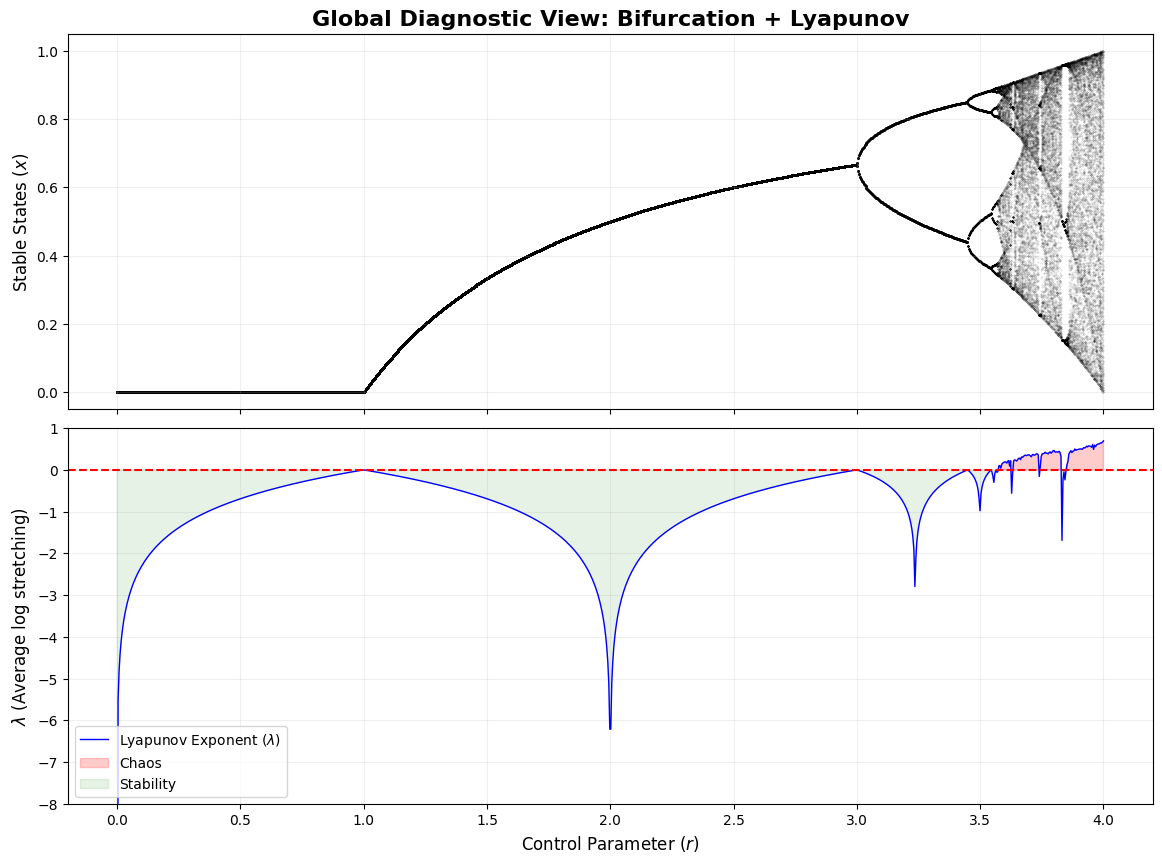

In [11]:
def generate_diagnostic_dashboard(r_min=0, r_max=4.0, resolution=1000):
    rs = np.linspace(r_min, r_max, resolution)

    burn = 400          # transient to discard (for BOTH diagnostics)
    bif_keep = 200      # points to plot in bifurcation
    lyap_keep = 600     # points to average for Lyapunov (can differ from bif_keep)

    # Data storage
    bifur_r = []
    bifur_x = []
    lyapunovs = []

    eps = 1e-12

    for r in rs:
        x = 0.1
        lyap_sum = 0.0
        lyap_count = 0

        total_iter = burn + max(bif_keep, lyap_keep)

        for i in range(total_iter):
            # derivative at current state
            f_prime = abs(r * (1 - 2 * x))

            # update
            x = r * x * (1 - x)

            # after burn-in: accumulate Lyapunov (for lyap_keep steps)
            if burn <= i < burn + lyap_keep:
                lyap_sum += np.log(f_prime + eps)
                lyap_count += 1

            # after burn-in: record bifurcation points (for bif_keep steps)
            if i >= burn + (max(bif_keep, lyap_keep) - bif_keep):
                bifur_r.append(r)
                bifur_x.append(x)

        lyapunovs.append(lyap_sum / lyap_count)

    lyapunovs = np.array(lyapunovs)

    # --- PLOTTING ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    plt.subplots_adjust(hspace=0.05)

    # Top: Bifurcation Diagram
    ax1.scatter(bifur_r, bifur_x, s=0.1, color='black', alpha=0.2)
    ax1.set_title("Global Diagnostic View: Bifurcation + Lyapunov", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Stable States ($x$)", fontsize=12)
    ax1.grid(True, alpha=0.2)

    # Bottom: Lyapunov Exponent
    ax2.plot(rs, lyapunovs, color='blue', lw=1, label=r'Lyapunov Exponent ($\lambda$)')
    ax2.axhline(0, color='red', lw=1.5, ls='--')

    ax2.fill_between(rs, lyapunovs, 0, where=(lyapunovs > 0), color='red', alpha=0.2, label='Chaos')
    ax2.fill_between(rs, lyapunovs, 0, where=(lyapunovs <= 0), color='green', alpha=0.1, label='Stability')

    ax2.set_ylabel(r"$\lambda$ (Average log stretching)", fontsize=12)
    ax2.set_xlabel("Control Parameter ($r$)", fontsize=12)
    ax2.set_ylim(-8, 1)
    ax2.legend(loc='lower left')
    ax2.grid(True, alpha=0.2)

    plt.show()

generate_diagnostic_dashboard()


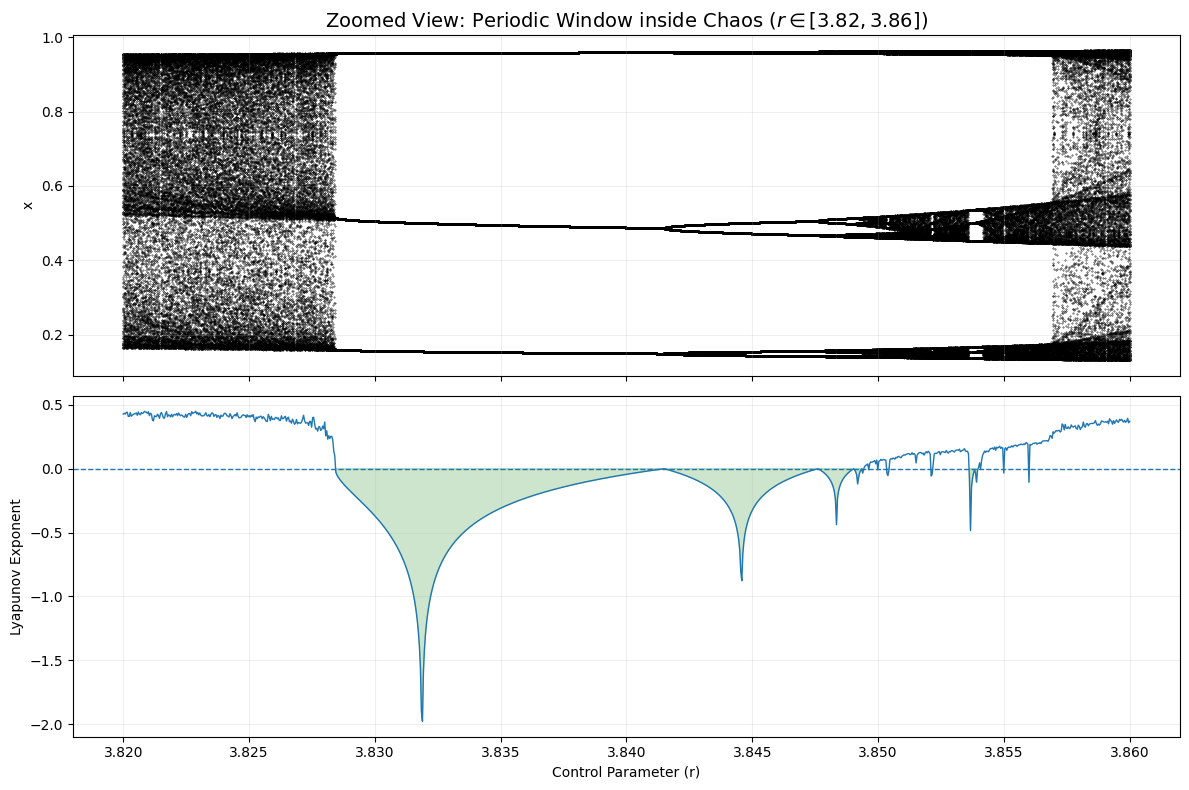

In [12]:
def generate_zoom_dashboard(r_min=3.82, r_max=3.86, resolution=1000):
    rs = np.linspace(r_min, r_max, resolution)
    burn = 800
    bif_keep = 200
    lyap_keep = 1200

    bifur_r, bifur_x, lyapunovs = [], [], []
    eps = 1e-12

    total_iter = burn + max(bif_keep, lyap_keep)

    for r in rs:
        x = 0.2
        lyap_sum = 0.0

        for i in range(total_iter):

          # accumulate lyapunov after burn-in using current x (x_t)
          if burn <= i < burn + lyap_keep:
              f_prime = abs(r * (1 - 2 * x))      # f'(x_t)
              lyap_sum += np.log(f_prime + eps)

          # iterate next
          x = r * x * (1 - x)

          # record bifurcation points at the end (x now is x_{t+1})
          if i >= total_iter - bif_keep:
              bifur_r.append(r)
              bifur_x.append(x)


        lyapunovs.append(lyap_sum / lyap_keep)

    lyapunovs = np.array(lyapunovs)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.scatter(bifur_r, bifur_x, s=0.1, color='black')
    ax1.set_title(f"Zoomed View: Periodic Window inside Chaos ($r \\in [{r_min}, {r_max}]$)", fontsize=14)
    ax1.set_ylabel("x")
    ax1.grid(alpha=0.2)

    ax2.plot(rs, lyapunovs, lw=1)
    ax2.axhline(0, lw=1, ls='--')

    ax2.fill_between(rs, lyapunovs, 0, where=(lyapunovs <= 0), color='green', alpha=0.2, label='Stability')

    ax2.set_ylabel("Lyapunov Exponent")
    ax2.set_xlabel("Control Parameter (r)")
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

generate_zoom_dashboard()
